In [19]:
import sys
import math
import matplotlib.pyplot as plt
import pandas as pd
import heapq


In [20]:
def ler_tsp_arquivo(caminho_arquivo):
    coords = []
    lendo = False

    with open(caminho_arquivo, 'r') as f:
        for linha in f:
            linha = linha.strip()

            if linha == "NODE_COORD_SECTION":
                lendo = True
                continue

            if linha == "EOF":
                break

            if lendo:
                partes = linha.split()
                id = int(partes[0])
                x = float(partes[1])
                y = float(partes[2])
                coords.append((id, x, y))

    return coords


In [21]:
def calcular_distancia(cidade1, cidade2):
    _, xi, yi = cidade1
    _, xj, yj = cidade2

    dist = math.sqrt((xi - xj)**2 + (yi - yj)**2)
    return math.floor(0.5 + dist)

In [22]:
def criar_matriz_distancias(coords):
    n = len(coords)

    matriz = [[0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if i != j:
                matriz[i][j] = calcular_distancia(coords[i], coords[j])

    return matriz

def imprimir_matriz_com_ids(coords, matriz):
    ids = [cidade[0] for cidade in coords]

    print("     ", end="")
    for id_cidade in ids:
        print(f"{id_cidade:6}", end="")
    print()

    for i, linha in enumerate(matriz):
        print(f"{ids[i]:5}", end="")
        for valor in linha:
            print(f"{valor:6}", end="")
        print()

def plotar_grafo(coords, matriz):
    plt.figure(figsize=(18, 8))

    n = len(coords)

    # desenhar todas as arestas
    for i in range(n):
        _, x1, y1 = coords[i]

        for j in range(i + 1, n):

            peso = matriz[i][j]

            if peso != 0:
                _, x2, y2 = coords[j]

                # linha da aresta
                plt.plot(
                    [x1, x2],
                    [y1, y2],
                    alpha=0.3
                )

                # peso no meio da aresta
                xm = (x1 + x2) / 2
                ym = (y1 + y2) / 2

                plt.text(
                    xm,
                    ym,
                    str(peso),
                    fontsize=7
                )

    # desenhar vértices
    for i, (_, x, y) in enumerate(coords):
        plt.scatter(x, y, s=100)

        plt.text(
            x,
            y,
            str(i + 1),
            fontsize=12,
            verticalalignment='bottom',
            horizontalalignment='right'
        )

    plt.title("Grafo Completo")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)

    plt.show()

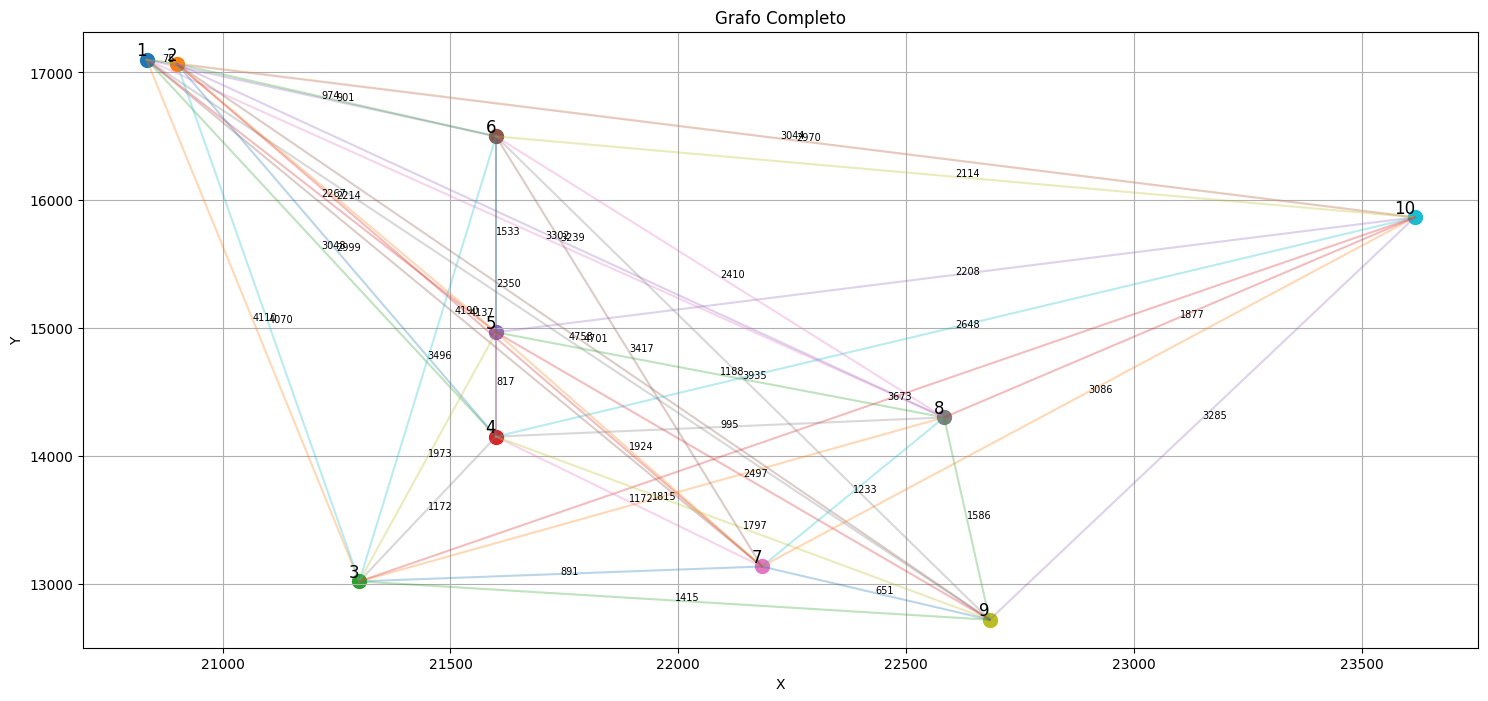

[[0, 75, 4110, 3048, 2267, 974, 4190, 3302, 4758, 3044],
 [75, 0, 4070, 2999, 2214, 901, 4137, 3239, 4701, 2970],
 [4110, 4070, 0, 1172, 1973, 3496, 891, 1815, 1415, 3673],
 [3048, 2999, 1172, 0, 817, 2350, 1172, 995, 1797, 2648],
 [2267, 2214, 1973, 817, 0, 1533, 1924, 1188, 2497, 2208],
 [974, 901, 3496, 2350, 1533, 0, 3417, 2410, 3935, 2114],
 [4190, 4137, 891, 1172, 1924, 3417, 0, 1233, 651, 3086],
 [3302, 3239, 1815, 995, 1188, 2410, 1233, 0, 1586, 1877],
 [4758, 4701, 1415, 1797, 2497, 3935, 651, 1586, 0, 3285],
 [3044, 2970, 3673, 2648, 2208, 2114, 3086, 1877, 3285, 0]]

In [23]:
coords = ler_tsp_arquivo("tsp10.tsp")
matriz = criar_matriz_distancias(coords)
plotar_grafo(coords,matriz)
matriz


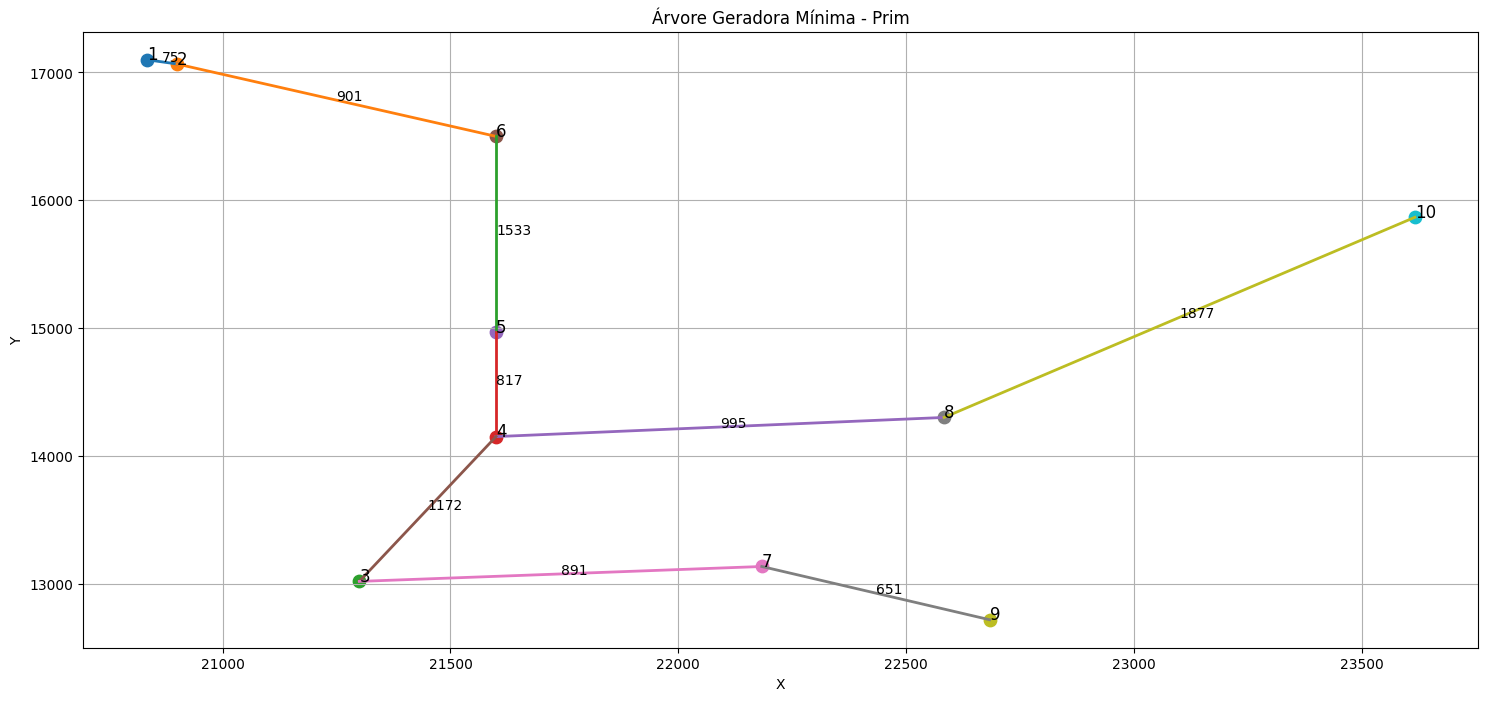

In [24]:
#Prim

def prim(matriz):
    n = len(matriz)

    visitado = [False] * n
    chave = [float('inf')] * n
    pai = [-1] * n

    agm = []
    custo_total = 0

    # começa no índice 0, que representa o vértice 1
    chave[0] = 0
    heap = [(0, 0)]  # (peso, vertice)

    while heap:
        peso, vertice = heapq.heappop(heap)

        if visitado[vertice]:
            continue

        visitado[vertice] = True
        custo_total += peso

        if pai[vertice] != -1:
            agm.append((
                chave[vertice],
                vertice + 1,
                pai[vertice] + 1
            ))

        for vizinho in range(n):
            peso_aresta = matriz[vertice][vizinho]

            if (
                peso_aresta != 0
                and not visitado[vizinho]
                and peso_aresta < chave[vizinho]
            ):
                chave[vizinho] = peso_aresta
                pai[vizinho] = vertice
                heapq.heappush(heap, (peso_aresta, vizinho))

    return agm, custo_total


def plotar_agm(coords, agm):
    plt.figure(figsize=(18, 8))

    for i, (_, x, y) in enumerate(coords):
        plt.scatter(x, y, s=80)
        plt.text(x, y, str(i + 1), fontsize=12)

    for peso, vertice, pai in agm:
        _, x1, y1 = coords[pai - 1]
        _, x2, y2 = coords[vertice - 1]

        plt.plot([x1, x2], [y1, y2], linewidth=2)

        plt.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            str(peso),
            fontsize=10
        )

    plt.title("Árvore Geradora Mínima - Prim")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

    plt.show()

agm, custo = prim(matriz)
plotar_agm(coords, agm)


In [ ]:
#Emparelhamento Perfeito

def encontrar_vertices_impares(agm, n):
    grau = [0] * n

    for peso, vertice, pai in agm:
        grau[vertice - 1] += 1
        grau[pai - 1] += 1

    impares = []

    for i in range(n):
        if grau[i] % 2 != 0:
            impares.append(i + 1)

    return impares

impares = encontrar_vertices_impares(agm, len(matriz))


def emparelhamento_perfeito_minimo(impares, matriz):
    melhor_pares = []
    melhor_custo = float("inf")

    def menor_custo(vertices_restantes, pares_atual, custo_atual):
        nonlocal melhor_pares, melhor_custo

        if not vertices_restantes:
            if custo_atual < melhor_custo:
                melhor_custo = custo_atual
                melhor_pares = pares_atual.copy()
            return

        # poda simples
        if custo_atual >= melhor_custo:
            return

        v = vertices_restantes[0]

        for i in range(1, len(vertices_restantes)):
            u = vertices_restantes[i]

            peso = matriz[v - 1][u - 1]

            novos_restantes = (
                vertices_restantes[1:i] +
                vertices_restantes[i + 1:]
            )

            pares_atual.append((peso,v, u))
            menor_custo(novos_restantes, pares_atual, custo_atual + peso)
            pares_atual.pop()

    if len(impares) % 2 != 0:
        raise ValueError("A quantidade de vértices ímpares deve ser par.")

    menor_custo(impares, [], 0)

    return melhor_pares, melhor_custo


emparelhamento, custo_emp = emparelhamento_perfeito_minimo(impares,matriz)
agm.extend(emparelhamento)
plotar_agm(coords, agm)